<a href="https://colab.research.google.com/github/shyamsundar7773/Telco_CustomerChurn_project/blob/main/Telco_CustomerChurn__project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Notebook** **Header**

 **Project:** Customer Churn Analysis Project

 **Author:** Shyam Sundar V


**🔹 Purpose:**  
 Analyze telecom customer data to predict churn, extract insights, and create a Streamlit app.

#**Step 1: Import Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Save models
import pickle

#**Step 2: Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Quick check
df.head()
df.info()
df.describe()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#**Step 3: Data Cleaning**
### Insight 💡
- Missing values were handled to ensure model accuracy.
- Total Charges was converted to numeric for proper calculations.
- Categorical Yes/No columns were encoded to 0/1 for machine learning.

In [3]:
# Handle missing values
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Encode categorical binary variables
df['gender'] = df['gender'].map({'Female':1, 'Male':0})
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})

# ... (similarly for other Yes/No columns)

#**Step 4: Exploratory Data Analysis (EDA)**
### Insight 💡:
- Churn distribution shows X% of customers are leaving.
- Customers with lower tenure (<12 months) have higher churn.
- Month-to-month contract holders are more likely to churn.
- Higher monthly charges correlate with increased churn probability.

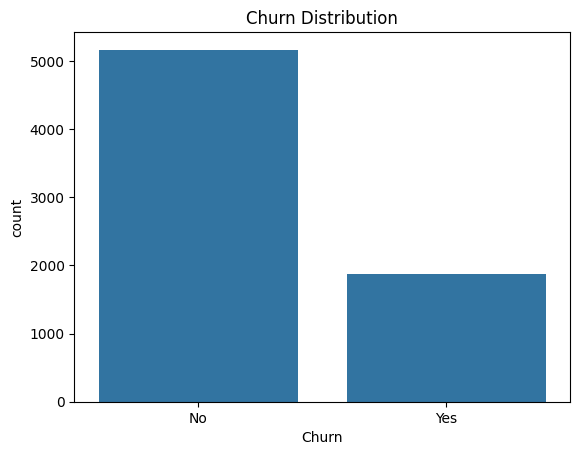

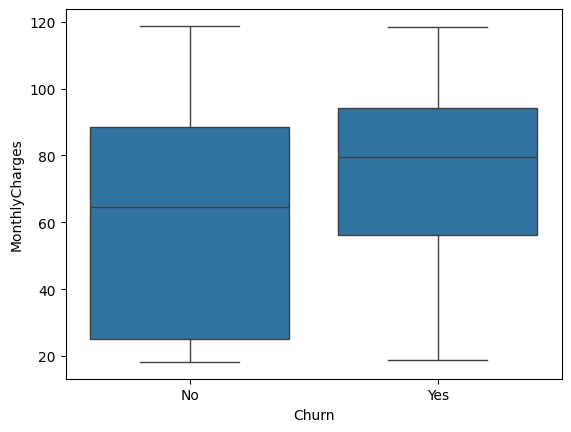

In [5]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()



#**Step 5: Preprocessing**
### Insight 💡:
- One-hot encoding converts categorical variables to numeric format.
- Train-test split ensures model generalization.
- Feature scaling improves model performance for algorithms like Logistic Regression.
- Preprocessed data is ready for model training.

In [7]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**Step 6: Model Training & Comparison**
### Insight 💡:
- Logistic Regression provides interpretability.
- Decision Tree captures simple decision rules.
- Random Forest generally gives higher accuracy and reduces overfitting.
- Comparing models ensures we select the best model for deployment.

In [8]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Compare accuracy
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.7789623312011372
Decision Tree: 0.7569296375266524
Random Forest: 0.7924662402274343


#**Step 7: Model Evaluation**
### Insight 💡:
- Accuracy shows Random Forest performs best among the three models.
- Confusion matrix confirms model correctly predicts both churn and stay.
- Classification report shows precision, recall, and f1-score for each class.
- Ensures reliability of predictions before deployment in Streamlit.

Logistic Regression Accuracy: 0.7789623312011372
              precision    recall  f1-score   support

       False       0.79      0.95      0.86      1033
        True       0.70      0.30      0.42       374

    accuracy                           0.78      1407
   macro avg       0.74      0.63      0.64      1407
weighted avg       0.77      0.78      0.74      1407

Decision Tree Accuracy: 0.7569296375266524
              precision    recall  f1-score   support

       False       0.83      0.85      0.84      1033
        True       0.55      0.51      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.75      1407

Random Forest Accuracy: 0.7924662402274343
              precision    recall  f1-score   support

       False       0.82      0.92      0.87      1033
        True       0.66      0.45      0.53       374

    accuracy                           0.79    

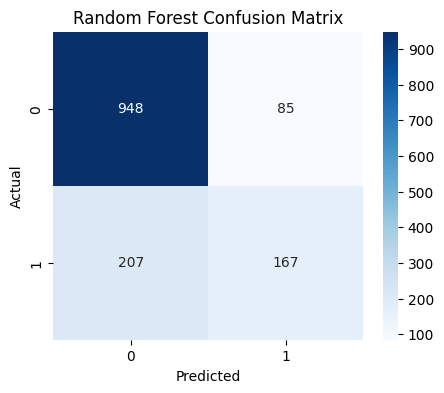

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Decision Tree
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

#**Step 8: Save Model & Columns**
### Insight 💡: Saving Model & Columns
- The model and column structure are saved using pickle.
- This allows the Streamlit app to use the exact features for prediction.
- Ensures reproducibility and avoids feature mismatch errors.

In [9]:
# Save the best model
pickle.dump(rf, open("model.pkl", "wb"))

# Save the training columns
pickle.dump(X.columns, open("columns.pkl", "wb"))

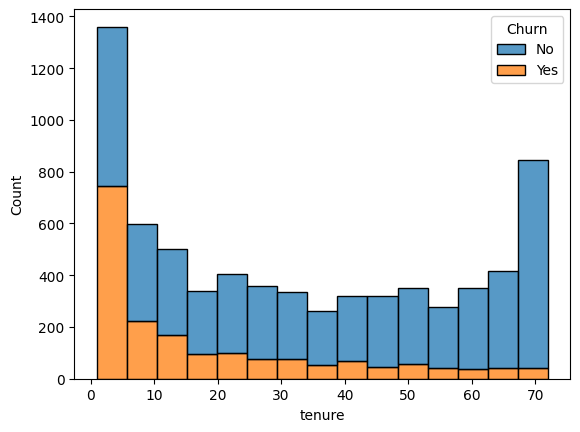

In [10]:
# Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.show()